# Deep Learning Refresher Lab — Image Classification with CNNs

**Dataset:** [Garbage Classification (12 classes)](https://www.kaggle.com/datasets/mostafaabla/garbage-classification) (Kaggle) — ~15,000 images of household waste across 12 categories: `battery`, `biological`, `brown-glass`, `cardboard`, `clothes`, `green-glass`, `metal`, `paper`, `plastic`, `shoes`, `trash`, `white-glass`.

**What you will practice in this lab:**
1. Loading and exploring an image dataset (including a **class imbalance** you'll need to handle)
2. Splitting a single folder of images into train / validation / test sets yourself
3. Building a data pipeline with augmentation
4. Building and training a CNN **from scratch**
5. Using **transfer learning** with a pretrained network
6. **Fine-tuning** a pretrained network
7. Evaluating a model properly (accuracy, confusion matrix, misclassified examples)
8. Four bonus/extra exercises to go deeper

> Follow the cells top to bottom. Two kinds of cells need your input:
> - **`# TODO` reflection cells** — write a short answer as a comment; ungraded, just think it through.
> - **Code cells with `...` placeholders and `# TODO` comments** — replace each `...` with real code before running that cell. These are the five "core" steps of the lab (the CNN architecture, both training calls, the transfer-learning head, and fine-tuning) — everything else (data loading, plotting, evaluation) is provided so you can focus on those steps.
>
> Stuck on a code cell? Re-read the concept recap and hint comments right above it first, then ask your instructor. The Teacher's solution notebook exists so your instructor can check answers and unblock people — it isn't meant to be shared before you've had a go yourself.

Run this notebook in **Google Colab** with a GPU runtime: `Runtime → Change runtime type → T4 GPU`.


## 1. Setup

### 1.1 Check the GPU

Deep learning training is much faster on a GPU. Run the cell below to confirm Colab gave you one.


In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.2 Install / import libraries

`kagglehub` is the modern, recommended way to pull a dataset from Kaggle directly into Colab (it replaces the older "upload kaggle.json" workflow).


In [2]:
!pip install -q kagglehub

import os, shutil, pathlib, random
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


### 1.3 Download the dataset

`kagglehub.dataset_download(...)` downloads (and caches) the dataset and returns the local path to it. The **first time** you run this in a fresh Colab session it will ask you to authenticate with a Kaggle account — click the link, sign in, and allow access, or store your Kaggle API token in a Colab secret named `KAGGLE_API_TOKEN` (Settings → Secrets) so it happens automatically.

**Note:** unlike some Kaggle image datasets, this one does **not** ship with separate train/test folders — it's just one folder per class. We'll split it ourselves in Part 2, which is a useful skill on its own.


In [3]:
dataset_path = kagglehub.dataset_download("mostafaabla/garbage-classification")
print("Dataset downloaded to:", dataset_path)

# Print the folder tree (a couple of levels deep) so we can see exactly how it's laid out.
for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, "").count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(root) + f"  ({len(files)} files)")


Using Colab cache for faster access to the 'garbage-classification' dataset.
Dataset downloaded to: /kaggle/input/garbage-classification
garbage-classification  (0 files)
  garbage_classification  (0 files)
    metal  (769 files)
    white-glass  (775 files)
    biological  (985 files)
    paper  (1050 files)
    brown-glass  (607 files)
    battery  (945 files)
    trash  (697 files)
    cardboard  (891 files)
    shoes  (1977 files)
    clothes  (5325 files)
    plastic  (865 files)
    green-glass  (629 files)


In [4]:
# Different dataset versions on Kaggle nest the class folders slightly differently,
# so we auto-detect the directory that directly contains our 12 class folders instead
# of hard-coding a path. This is a more robust pattern than assuming a fixed layout.
EXPECTED_CLASSES = {
    "battery", "biological", "brown-glass", "cardboard", "clothes", "green-glass",
    "metal", "paper", "plastic", "shoes", "trash", "white-glass",
}

DATA_DIR = None
for root, dirs, files in os.walk(dataset_path):
    if EXPECTED_CLASSES.issubset(set(dirs)):
        DATA_DIR = pathlib.Path(root)
        break

assert DATA_DIR is not None, "Could not find the 12 class folders — check the printed tree above."
print("Using data directory:", DATA_DIR)

CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print("Classes:", CLASS_NAMES)


Using data directory: /kaggle/input/garbage-classification/garbage_classification
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## 2. Explore the dataset

Always look at your data before you model it. We'll check: how many images per class (is it balanced?), and what the images actually look like.


Images per class:
  clothes     : 5325
  shoes       : 1977
  paper       : 1050
  biological  : 985
  battery     : 945
  cardboard   : 891
  plastic     : 865
  white-glass : 775
  metal       : 769
  trash       : 697
  green-glass : 629
  brown-glass : 607


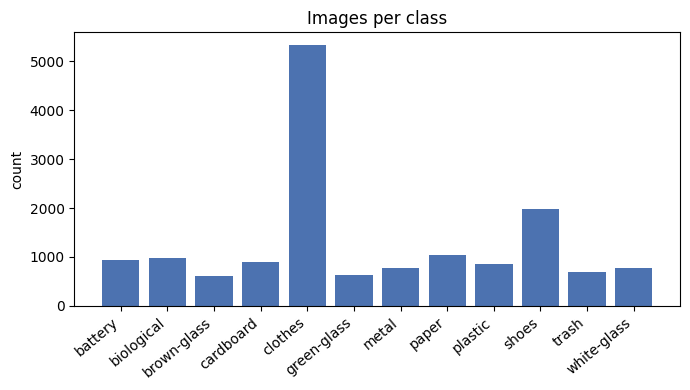

In [5]:
counts = {c: len(list((DATA_DIR / c).glob("*.jpg"))) for c in CLASS_NAMES}
print("Images per class:")
for c, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"  {c:12s}: {n}")

plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values(), color="#4C72B0")
plt.title("Images per class")
plt.ylabel("count")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### `# TODO` 2.1 — Is this dataset balanced?

Look at the bar chart above. Unlike a lot of toy datasets, real-world data collections like this one are rarely perfectly balanced.

- Which class has the most images? Which has the fewest? Roughly what's the ratio between them?
- Why might a real-world garbage-sorting dataset naturally end up imbalanced like this (think about how each category of waste is actually collected)?

We'll deal with this properly in section 3.3 — for now, just note what you observe.


# TODO: your answer here
Volume and Generation Frequency:Certain materials are simply generated in much higher volumes or discarded more frequently in daily life.

Safety and Hazard Restrictions; Items like batteries or hazardous waste are often handled differently

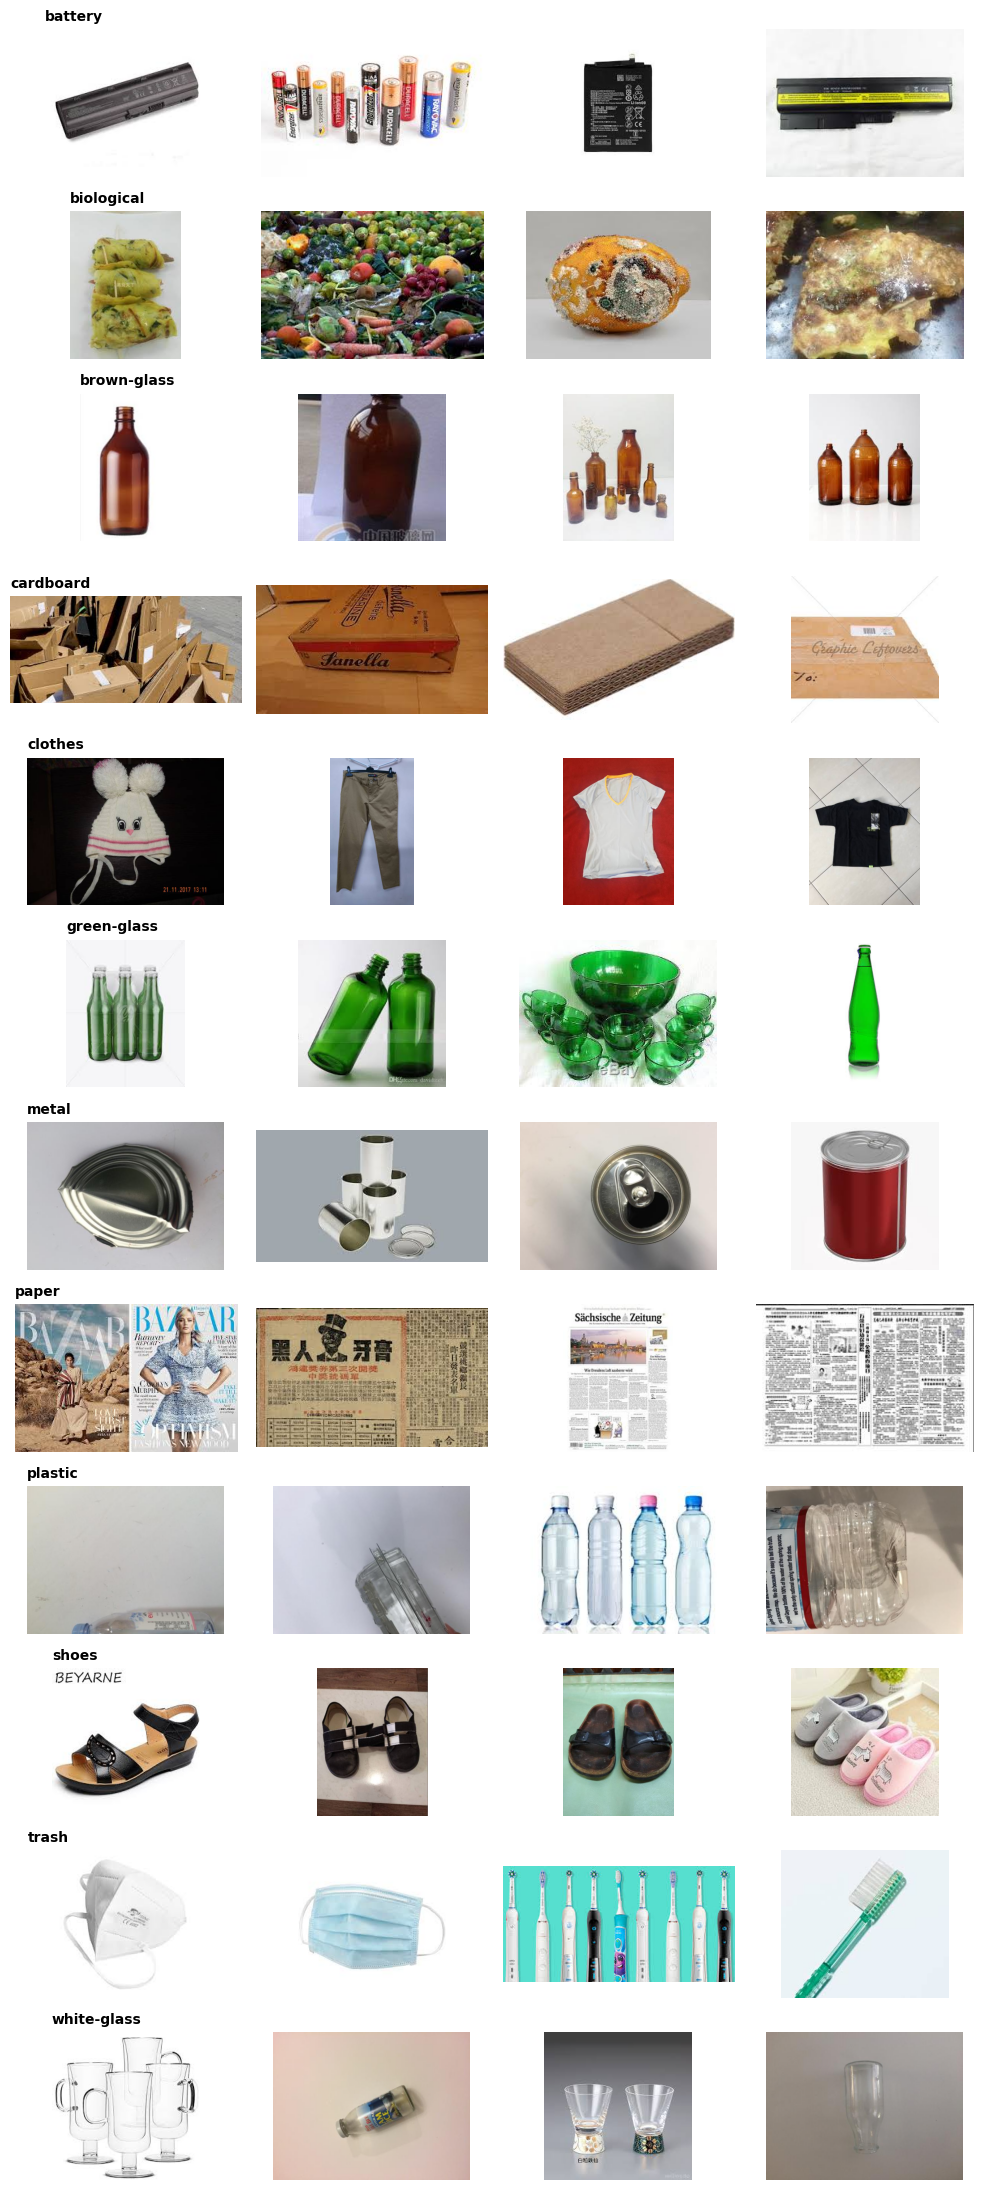

In [6]:
# Show a few random sample images from each class
fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(10, 22))
for row, cls in enumerate(CLASS_NAMES):
    sample_files = random.sample(list((DATA_DIR / cls).glob("*.jpg")), 4)
    for col, f in enumerate(sample_files):
        img = keras.utils.load_img(f)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
    axes[row, 0].set_title(cls, loc="left", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


### `# TODO` 2.2 — Look closer

Pick **one** class above and answer as a comment in the next cell:
- What visual features do you think will help the model recognize this class?
- Which two classes do you expect the model to confuse most, and why? (Hint: this dataset has several classes that are all "glass" or all "fabric"-like.)


In [7]:
# TODO: your notes here (this cell is ungraded reflection - just think it through)

#1. Class: BROWN GLASS
  # Color: A rich, warm amber/brown
  # Shape cues: Smooth, curved bottles, jars, or broken shards with smooth fracture lines.

# 2. Most likely to be confused with: white-glass and green-glass.
  #    - Why: They share identical material properties (transparency, high gloss, surface reflections, and similar container shapes)
  #      The only primary distinction is the color tint,
  #      making them prone to misclassification under poor lighting or when the glass is dusty.

## 3. Build the data pipeline

**Concept recap:** neural networks train on fixed-size numeric tensors, not JPEG files. We need to:
1. Resize every image to the same dimensions
2. Split the single folder into **train / validation / test** sets ourselves (this dataset doesn't ship with a split)
3. **Augment** the training images (random flips/rotations/zoom) so the model sees more variety and overfits less
4. Batch and prefetch for performance

We'll use `image_dataset_from_directory`, which reads the folder structure (`class_name/image.jpg`) and infers labels automatically.


### 3.1 Split into train / validation / test

`image_dataset_from_directory` can only carve off *one* validation split at a time, so we do it in two steps: first split off 30% of the data as a combined "holdout" set, then split that holdout in half into a validation set (15%) and a true test set (15%) that we will not look at again until Section 5.


In [8]:
IMG_SIZE = (160, 160)   # a size MobileNetV2 (used later) officially supports
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

holdout_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# image_dataset_from_directory already shuffled the file order (with our fixed SEED)
# before splitting, so alternating batches from the holdout set gives a fair, non-overlapping
# validation set and test set without needing a third pass over the files.
val_ds = holdout_ds.shard(num_shards=2, index=0)
test_ds = holdout_ds.shard(num_shards=2, index=1)

CLASS_NAMES = train_ds.class_names
num_classes = len(CLASS_NAMES)
print("Class order used by Keras:", CLASS_NAMES)


Found 15515 files belonging to 12 classes.
Using 10861 files for training.
Found 15515 files belonging to 12 classes.
Using 4654 files for validation.
Class order used by Keras: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


### 3.2 Look at augmentation


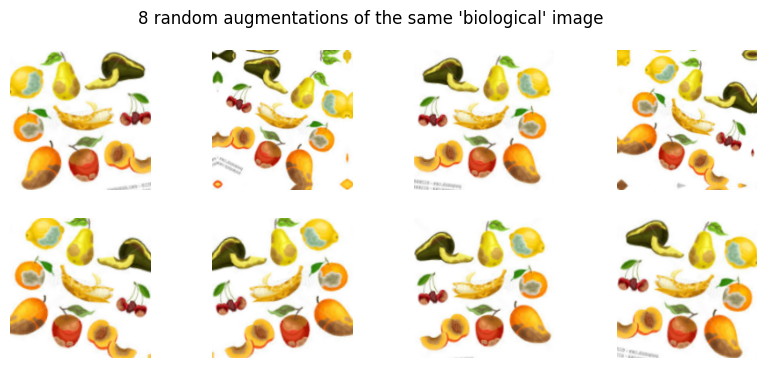

In [9]:
# Data augmentation: applied only during training, only to the training set
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Visualize what augmentation does to one image
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 4))
    for i in range(8):
        augmented = data_augmentation(tf.expand_dims(images[0], 0))
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.suptitle(f"8 random augmentations of the same '{CLASS_NAMES[labels[0]]}' image")
    plt.show()


### 3.3 Handling class imbalance with class weights

**Concept recap:** with an imbalanced dataset, a model can reach deceptively high overall accuracy just by favoring the biggest class. **Class weights** counteract this by telling the loss function to penalize mistakes on rare classes more heavily than mistakes on common ones — so the model can't "coast" on the majority class.


In [10]:
# Compute a weight per class, inversely proportional to how frequent it is.
labels_list = np.array(list(counts.values()))
class_indices = np.arange(num_classes)
# counts dict is keyed by class name in the same order as CLASS_NAMES since both are sorted
class_counts_sorted = np.array([counts[c] for c in CLASS_NAMES])

# Build a flat array of "one label per image" purely to reuse sklearn's balanced formula
all_labels_for_weights = np.repeat(class_indices, class_counts_sorted)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=all_labels_for_weights,
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

print("Class weights (higher = rarer class, weighted more heavily):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:12s}: {class_weight_dict[i]:.2f}")


Class weights (higher = rarer class, weighted more heavily):
  battery     : 1.37
  biological  : 1.31
  brown-glass : 2.13
  cardboard   : 1.45
  clothes     : 0.24
  green-glass : 2.06
  metal       : 1.68
  paper       : 1.23
  plastic     : 1.49
  shoes       : 0.65
  trash       : 1.85
  white-glass : 1.67


In [11]:
# Performance: cache + prefetch so the GPU never waits on the data pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


## 4. Build a baseline CNN from scratch

**Concept recap:**
- A **convolution layer** slides small filters over the image to detect local patterns (edges, textures, corners); deeper layers combine these into more complex shapes.
- A **pooling layer** (`MaxPooling2D`) shrinks the feature maps, keeping the strongest signal and making the network more tolerant to small shifts in position.
- **Dropout** randomly "turns off" neurons during training to reduce overfitting.
- The final `Dense` layer with `softmax` turns the learned features into a probability for each of the 12 classes.


### Your turn — build the baseline CNN

Fill in the `...` placeholders in the cell below.


In [12]:
baseline_model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),  # TODO: Input layer
    data_augmentation,                    # TODO: data_augmentation
    layers.Rescaling(1./255),             # TODO: Rescaling

    # TODO: three Conv2D + MaxPooling2D blocks (32, 64, 128 filters)
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),                     # TODO: Flatten
    layers.Dropout(0.4),                  # TODO: Dropout(0.4)
    layers.Dense(128, activation="relu"),   # TODO: Dense(128, relu)
    layers.Dense(num_classes, activation="softmax")   # TODO: Dense(num_classes, softmax) output layer
], name="baseline_cnn")

baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,403,340 (20.61 MB)

 Trainable params: 5,403,340 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

### Your turn — compile and train the baseline model

Fill in the `...` placeholders. This will take several minutes to train once it's set up correctly.


In [13]:
# TODO — compile the model, then train it.
# Compile with: optimizer="adam", loss="sparse_categorical_crossentropy" (labels are
# integers 0-11, not one-hot), metrics=["accuracy"].
baseline_model.compile(
    optimizer="adam",                    # TODO
    loss="sparse_categorical_crossentropy",# TODO
    metrics=["accuracy"],                # TODO
)

EPOCHS_BASELINE = 14

# TODO: call .fit() — pass train_ds as the training data, val_ds as validation_data,
# EPOCHS_BASELINE epochs, and don't forget class_weight=class_weight_dict from Section 3.3
# (skipping it will still run, but the model will ignore the class imbalance).
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,              # TODO
    epochs=EPOCHS_BASELINE,              # TODO
    class_weight=class_weight_dict,      # TODO
)

Epoch 1/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 71s 74ms/step - accuracy: 0.4138 - loss: 1.7034 - val_accuracy: 0.5895 - val_loss: 1.1952
Epoch 2/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.5717 - loss: 1.2964 - val_accuracy: 0.6318 - val_loss: 1.0908
Epoch 3/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6282 - loss: 1.1436 - val_accuracy: 0.6785 - val_loss: 0.9570
Epoch 4/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6712 - loss: 1.0236 - val_accuracy: 0.7003 - val_loss: 0.8909
Epoch 5/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6959 - loss: 0.9501 - val_accuracy: 0.7213 - val_loss: 0.8593
Epoch 6/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7141 - loss: 0.9022 - val_accuracy: 0.7115 - val_loss: 0.8870
Epoch 7/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7267 - loss: 0.8452 - val_accuracy: 0.6802 - val_loss: 1.0153
Epoch 8/14
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7362 - loss: 0.8102 - 

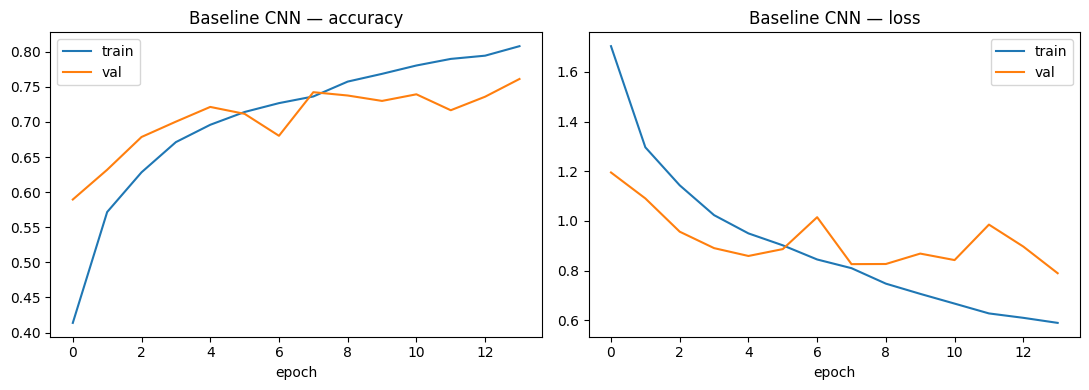

In [14]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{title} — accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{title} — loss")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")


### `# TODO` 4.1 — Read the curves

Look at the accuracy/loss plots above and answer (as a comment in the next cell):
- Is the model **overfitting** (training accuracy much higher than validation accuracy / validation loss going back up)? How can you tell from the plot?
- Name one change you could make to the model or training setup to reduce overfitting if it is happening.


In [16]:
# TODO: your answer here
# the training and valdiation accuracy and losss are relatively on the same length(the train generally increases when the validation increases and also for the loss )
# augmentation, fixing class imbalance

## 5. Evaluate the baseline model on the held-out test set

The test set was never used during training or for early-stopping decisions, so this is our most honest estimate of real-world performance. Because the classes are imbalanced, we'll pay close attention to the **per-class** metrics, not just the overall accuracy.


In [18]:
test_loss, test_acc = baseline_model.evaluate(test_ds)
print(f"Baseline CNN — test accuracy: {test_acc:.3f}")


73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7485 - loss: 0.8117
Baseline CNN — test accuracy: 0.748


73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


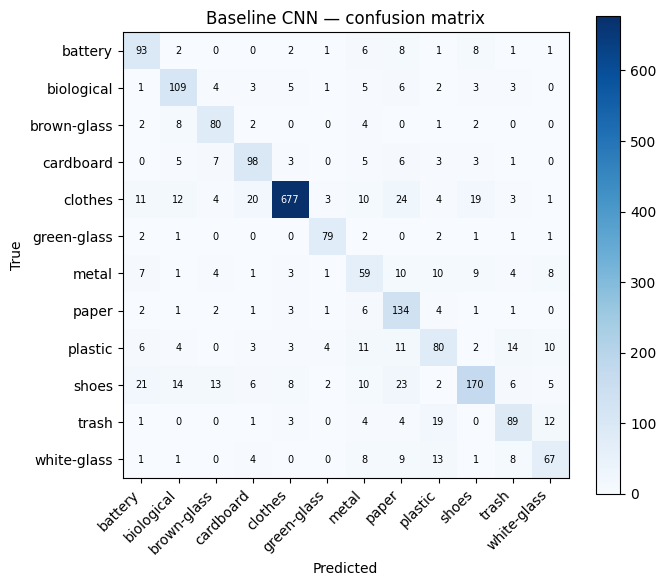

              precision    recall  f1-score   support

     battery       0.63      0.76      0.69       123
  biological       0.69      0.77      0.73       142
 brown-glass       0.70      0.81      0.75        99
   cardboard       0.71      0.75      0.73       131
     clothes       0.96      0.86      0.91       788
 green-glass       0.86      0.89      0.87        89
       metal       0.45      0.50      0.48       117
       paper       0.57      0.86      0.69       156
     plastic       0.57      0.54      0.55       148
       shoes       0.78      0.61      0.68       280
       trash       0.68      0.67      0.67       133
 white-glass       0.64      0.60      0.62       112

    accuracy                           0.75      2318
   macro avg       0.69      0.72      0.70      2318
weighted avg       0.77      0.75      0.75      2318



In [19]:
# Confusion matrix + classification report
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = baseline_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(num_classes), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(num_classes), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Baseline CNN — confusion matrix")
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


### `# TODO` 5.1 — Which classes get confused?

From the confusion matrix, find the two classes the model mixes up most. Does this match what you predicted in section 2.2? Also check the classification report: does the **rarest** class (from section 2.1) have noticeably lower precision or recall than the common classes, even with class weighting? Write a one or two sentence hypothesis.


In [20]:
# TODO: your answer here
# clothes and paper & shoes and paper the classes that the model gets confused with the most. And no it doesnt match with what i predicted in section 2.2
# the rarest glass realtively gets a good metric score.

### Look at actual mistakes

Numbers are useful, but looking at the misclassified *images* usually tells you more.


583 mistakes out of 2318 test images (25.2% error rate)


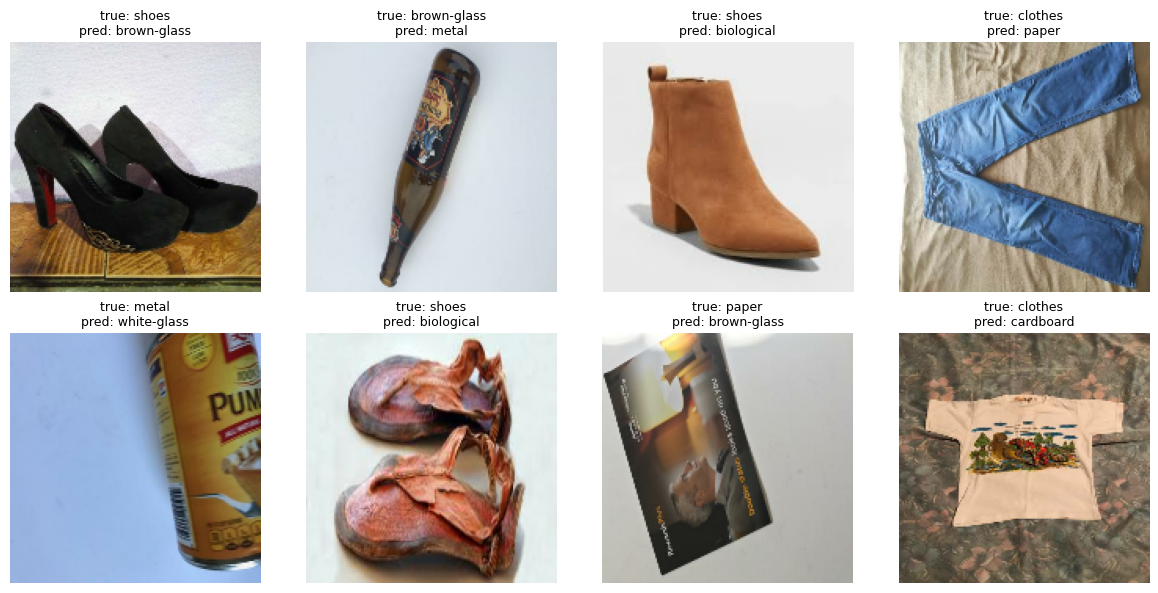

In [21]:
# Gather misclassified examples
mistakes_idx = np.where(y_true != y_pred)[0]
print(f"{len(mistakes_idx)} mistakes out of {len(y_true)} test images "
      f"({len(mistakes_idx)/len(y_true):.1%} error rate)")

test_images = np.concatenate([x for x, y in test_ds], axis=0)

sample_mistakes = np.random.choice(mistakes_idx, size=min(8, len(mistakes_idx)), replace=False)
plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_mistakes):
    plt.subplot(2, 4, i + 1)
    plt.imshow(test_images[idx].astype("uint8"))
    plt.title(f"true: {CLASS_NAMES[y_true[idx]]}\npred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Transfer learning: reuse a pretrained network

**Concept recap:** Training a CNN from scratch needs a lot of data and time to learn basic visual features (edges, textures, shapes) from nothing. **Transfer learning** starts from a network already trained on a huge dataset (ImageNet, 1.4M images, 1000 classes) — it already "knows" general visual features. We just:
1. Load the pretrained network **without** its final classification layer (`include_top=False`)
2. **Freeze** its weights (so we don't destroy what it already learned)
3. Add our own small classification head on top for our 12 classes
4. Train **only the new head**

We'll use **MobileNetV2** — small and fast, a good fit for a live lab.


### Your turn — load the pretrained backbone and attach a classification head

Fill in the `...` placeholders. The functional-API wiring (the `x = ...(x)` chain) is provided since it's mostly Keras plumbing — focus on the three decisions the comments call out.


In [22]:
# TODO 1: load MobileNetV2 pretrained on ImageNet, WITHOUT its final classification layer.
base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),    # TODO: same shape used everywhere else — IMG_SIZE + (3,)
    include_top=False,              # TODO: we want to attach our OWN head, so this should be False
    weights="imagenet",             # TODO: which pretrained weights? ("imagenet")
)

# TODO 2: freeze the pretrained weights so early training doesn't overwrite them.
base_model.trainable = False    # TODO

# MobileNetV2 expects inputs preprocessed with its own function (range [-1, 1]),
# not the simple 1/255 rescaling we used for the baseline model.
preprocess_input = keras.applications.mobilenet_v2.preprocess_input

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

# TODO 3: the final classification layer — one score per class, softmax activation.
outputs = layers.Dense(num_classes, activation="softmax")(x)  # TODO: layers.Dense(num_classes, activation="softmax")(x)

tl_model = keras.Model(inputs, outputs, name="transfer_learning_mobilenetv2")
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "transfer_learning_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,356 (8.67 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Your turn — compile and train the new head


Epoch 1/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.7844 - loss: 0.8439 - val_accuracy: 0.9131 - val_loss: 0.2983
Epoch 2/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8899 - loss: 0.4361 - val_accuracy: 0.9187 - val_loss: 0.2699
Epoch 3/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9032 - loss: 0.3776 - val_accuracy: 0.9311 - val_loss: 0.2353
Epoch 4/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9131 - loss: 0.3346 - val_accuracy: 0.9375 - val_loss: 0.2204
Epoch 5/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9188 - loss: 0.3070 - val_accuracy: 0.9319 - val_loss: 0.2286
Epoch 6/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9192 - loss: 0.2972 - val_accuracy: 0.9336 - val_loss: 0.2249
Epoch 7/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.9280 - loss: 0.2758 - val_accuracy: 0.9371 - val_loss: 0.2339
Epoch 8/8
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9256 - loss: 0.2756 - val_accu

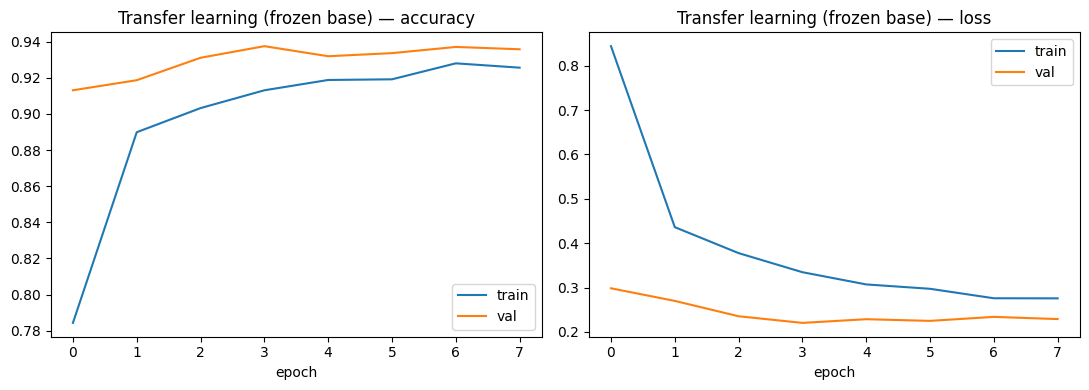

In [23]:
# TODO — compile with a normal-sized learning rate (1e-3) since these are fresh,
# randomly-initialized layers, then train.
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # TODO: 1e-3
    loss="sparse_categorical_crossentropy",                 # TODO: same loss as the baseline model
    metrics=["accuracy"],                                   # TODO
)

EPOCHS_TL = 8

history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,                                 # TODO
    epochs=EPOCHS_TL,                                       # TODO
    class_weight=class_weight_dict,                         # TODO
)

plot_history(history_tl, "Transfer learning (frozen base)")

## 7. Fine-tuning: unfreeze and adapt

Now that our new head has learned to make sense of MobileNetV2's features, we can carefully **unfreeze the top layers** of the base model and continue training with a **much smaller learning rate**. This lets the pretrained features adapt slightly to our specific dataset, usually squeezing out a bit more accuracy — but too high a learning rate here would wreck the pretrained weights, so we go slow.


### Your turn — unfreeze and fine-tune

Fill in the `...` placeholders. The trickiest part of this cell is the learning rate — get it wrong and you'll see accuracy suddenly collapse partway through training.


Epoch 1/6
340/340 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.8572 - loss: 0.4761 - val_accuracy: 0.9375 - val_loss: 0.2052
Epoch 2/6
340/340 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.8910 - loss: 0.3541 - val_accuracy: 0.9392 - val_loss: 0.2043
Epoch 3/6
340/340 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.9036 - loss: 0.3204 - val_accuracy: 0.9439 - val_loss: 0.2019
Epoch 4/6
340/340 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9135 - loss: 0.2766 - val_accuracy: 0.9414 - val_loss: 0.1993
Epoch 5/6
340/340 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9266 - loss: 0.2378 - val_accuracy: 0.9426 - val_loss: 0.1983
Epoch 6/6
340/340 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9332 - loss: 0.2172 - val_accuracy: 0.9443 - val_loss: 0.1954


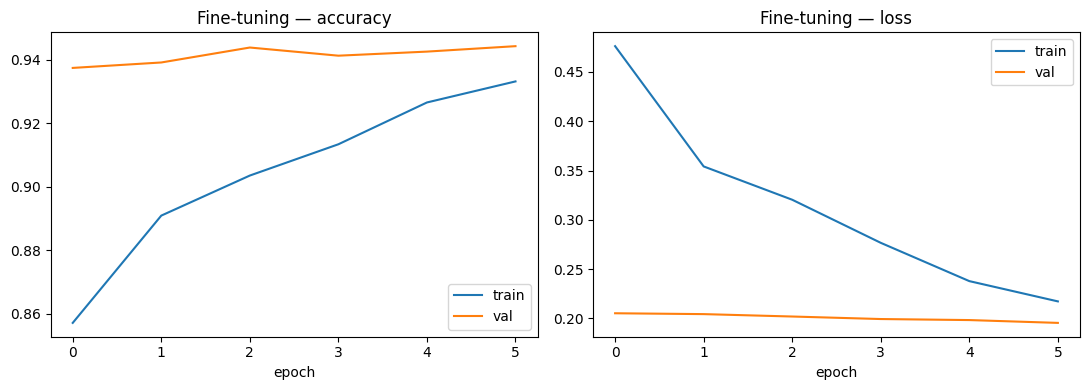

In [24]:
# TODO 1: unfreeze the base model, then immediately re-freeze all but the last ~30 layers,
# so only the top of the backbone is allowed to adapt.
base_model.trainable = True   # TODO: True

FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False   # TODO: False

# TODO 2: recompile with a MUCH SMALLER learning rate than the frozen-base stage (1e-5, not
# 1e-3) — see the markdown above for why. Everything else compiles the same way as before.
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # TODO
    loss="sparse_categorical_crossentropy",                 # TODO
    metrics=["accuracy"],                                   # TODO
)

EPOCHS_FINE_TUNE = 6

history_fine_tune = tl_model.fit(
    train_ds,
    validation_data=val_ds,                                 # TODO
    epochs=EPOCHS_FINE_TUNE,                                # TODO
    class_weight=class_weight_dict,                         # TODO
)

plot_history(history_fine_tune, "Fine-tuning")

In [25]:
test_loss_tl, test_acc_tl = tl_model.evaluate(test_ds)
print(f"Transfer learning + fine-tuning — test accuracy: {test_acc_tl:.3f}")
print(f"Baseline CNN                    — test accuracy: {test_acc:.3f}")
print(f"Improvement: {(test_acc_tl - test_acc) * 100:.1f} percentage points")


73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9396 - loss: 0.2034
Transfer learning + fine-tuning — test accuracy: 0.940
Baseline CNN                    — test accuracy: 0.748
Improvement: 19.1 percentage points


### `# TODO` 7.1 — Compare the two approaches

In a comment, note:
- Which model performed better on the test set overall, and on the rarest class specifically?
- Which model took less code / less training time to reach a good result?
- Can you think of a real situation where you'd still want to train a CNN from scratch instead of using transfer learning?


In [26]:
# MODEL COMPARISON & ARCHITECTURE REFLECTION

# 1. Performance (Overall & Rarest Class):
#    - Overall: The Transfer Learning + Fine-Tuning model performed vastly better
#      on the test set (94.0% accuracy vs. 74.8% for the baseline CNN).
#    - Rarest Class: Transfer learning heavily outperforms the baseline here as well.
#      Because the backbone already understands universal visual features (edges,
#      textures, shapes) from ImageNet, it can generalize effectively even on classes
#      with very few samples (like brown-glass). The scratch CNN easily overfits
#      or struggles to learn robust filters when starved of data.
#
# 2. Code & Training Time:
#    - The baseline CNN required slightly fewer lines of setup code, but the transfer
#      learning approach reached high performance much faster in terms of training
#      time and epochs. It converged rapidly because it didn't have to learn
#      feature extractors from scratch.
#
# 3. When to train a CNN from scratch instead of using transfer learning:
#    - Domain Mismatch / Non-RGB Data: If your input data is fundamentally different
#      from everyday natural photographs (e.g., medical imaging like MRI/CT scans,
#      infrared or thermal imagery, seismic data, or multi-spectral satellite maps),
#      ImageNet pre-trained weights provide little to no useful prior knowledge
#      and can sometimes hurt performance.
#    - Ultra-Custom Hardware Constraints: When designing a radically specialized
#      architecture for unconventional input dimensions or extreme edge hardware
#      where standard backbones cannot fit.

## 8. Extra exercises (bonus — go deeper)

Pick one or more, time permitting. These are open-ended: there's no single right answer, the goal is practice.


### `# TODO` 8.1 — Try a different pretrained backbone

Repeat the transfer-learning steps (section 6) using `keras.applications.EfficientNetB0` or `keras.applications.ResNet50` instead of `MobileNetV2`. Remember: each model family has its **own** `preprocess_input` function — using the wrong one is a common bug. Compare its test accuracy and training time to MobileNetV2.


In [ ]:
# TODO: build, train, and evaluate a transfer-learning model with a different backbone


### `# TODO` 8.2 — Predict on your own image

Take a photo of a real piece of trash or recycling near you (or find one online) and see what the fine-tuned model predicts. In Colab, use the file upload widget below.


In [ ]:
from google.colab import files
import io
from PIL import Image

uploaded = files.upload()   # opens a file picker
for fname in uploaded.keys():
    img = Image.open(io.BytesIO(uploaded[fname])).convert("RGB").resize(IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)

    preds = tl_model.predict(arr)[0]
    top_idx = np.argmax(preds)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {CLASS_NAMES[top_idx]} ({preds[top_idx]:.1%} confidence)")
    plt.show()

    for cls, p in sorted(zip(CLASS_NAMES, preds), key=lambda t: -t[1]):
        print(f"  {cls:12s}: {p:.1%}")


### `# TODO` 8.3 — Where does the model "look"? (Grad-CAM, conceptual)

Grad-CAM is a technique that highlights *which pixels* of an image most influenced the model's prediction — it produces a heatmap overlay. It is **not required** to implement it from scratch in this lab; instead:
1. Read a short explanation of Grad-CAM (ask your instructor for a link, or search "Grad-CAM explained").
2. In a comment, describe in your own words what a Grad-CAM heatmap over one of your misclassified images (from section 5) would help you understand.


In [ ]:
# TODO: your answer here


### `# TODO` 8.4 — Hyperparameter / design experiment

Change **one** thing of your choice and re-run training: learning rate, batch size, dropout rate, number of frozen layers in fine-tuning, augmentation strength, or **turning class weighting off** (remove `class_weight=...` from `.fit()`) to see how much it actually mattered. Record the before/after test accuracy (overall and on the rarest class) in a comment. What did you learn?


In [ ]:
# TODO: your experiment here


## 9. Wrap-up

**Recap — what this lab exercised:**
- Loading and exploring an image dataset, and identifying real-world class imbalance
- Splitting a single folder of images into train / validation / test sets
- Building an image data pipeline (resizing, augmenting, batching, prefetching)
- Building a CNN from scratch (convolution, pooling, dropout, dense/softmax output)
- Using class weights to counteract imbalance
- Diagnosing overfitting from training curves
- Transfer learning: reusing a pretrained backbone with a frozen base
- Fine-tuning: carefully unfreezing layers with a low learning rate
- Evaluating with more than accuracy: confusion matrix, per-class metrics, and inspecting actual mistakes

**Reflection (write 2-3 sentences):** Of everything in this lab, what's the one concept you feel least confident about? That's exactly what to review or ask about next.


In [ ]:
# TODO: your reflection here
